# Summary: AI vs Physics Models & Cross-Year RMSE Comparison

Aggregates results from the three experiment notebooks (2016, 2018, 2022) into
two summary plots.

**Prerequisites:** run the three experiment notebooks first so that `metrics.csv`
is saved in each figure directory.

| Year | Period | Models |
|---|---|---|
| 2016 | 2016-01-01 → 2016-05-12 | FCN3, HRES |
| 2018 | 2018-01-01 → 2018-05-20 | FCN3, HRES |
| 2022 | 2022-01-01 → 2022-01-28 | FCN3, GraphCast, Pangu, HRES |

All comparisons: +12 h lead, valid 12:00 UTC, obs = 12h trailing mean.


In [62]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path


In [63]:
FIG_BASE = Path('/cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures')
FIG_OUT  = FIG_BASE / 'comparison_summary'
FIG_OUT.mkdir(parents=True, exist_ok=True)

METRIC_PATHS = {
    '2016': FIG_BASE / 'fcn3_hres_2016'              / 'metrics.csv',
    '2018': FIG_BASE / 'fcn3_hres_2018'              / 'metrics.csv',
    '2022': FIG_BASE / 'fcn3_gc_pangu_hres_2022_12h' / 'metrics.csv',
}

STATIONS = {
    'SN88690': 'Hekkingen Fyr',
    'SN90490': 'Tromsoe-Langnes',
    'SN90760': 'Fakken',
}

CLR = {
    'FCN3':      '#E74C3C',
    'GraphCast': '#2980B9',
    'Pangu':     '#16A085',
    'HRES':      '#E67E22',
}

AI_MODELS      = ['FCN3', 'GraphCast', 'Pangu']
PHYSICS_MODELS = ['HRES']


## 1  Load Metrics from Experiment Notebooks

In [64]:
dfs = {}
for year, path in METRIC_PATHS.items():
    if not path.exists():
        print(f'WARNING: {path} not found. Run the {year} notebook first.')
        continue
    df = pd.read_csv(path, index_col=0)
    dfs[year] = df
    print(f'{year}: {df.shape[0]} rows, models={[c.split()[0] for c in df.columns if "RMSE" in c]}')

if not dfs:
    raise RuntimeError('No metrics CSVs found. Run all three experiment notebooks first.')


2016: 4 rows, models=['FCN3', 'HRES', 'ΔRMSE']
2018: 4 rows, models=['FCN3', 'HRES', 'ΔRMSE']
2022: 4 rows, models=['FCN3', 'GraphCast', 'HRES', 'Pangu', 'ΔRMSE', 'ΔRMSE', 'ΔRMSE']


## 2  AI-based vs Physics-based Model Performance

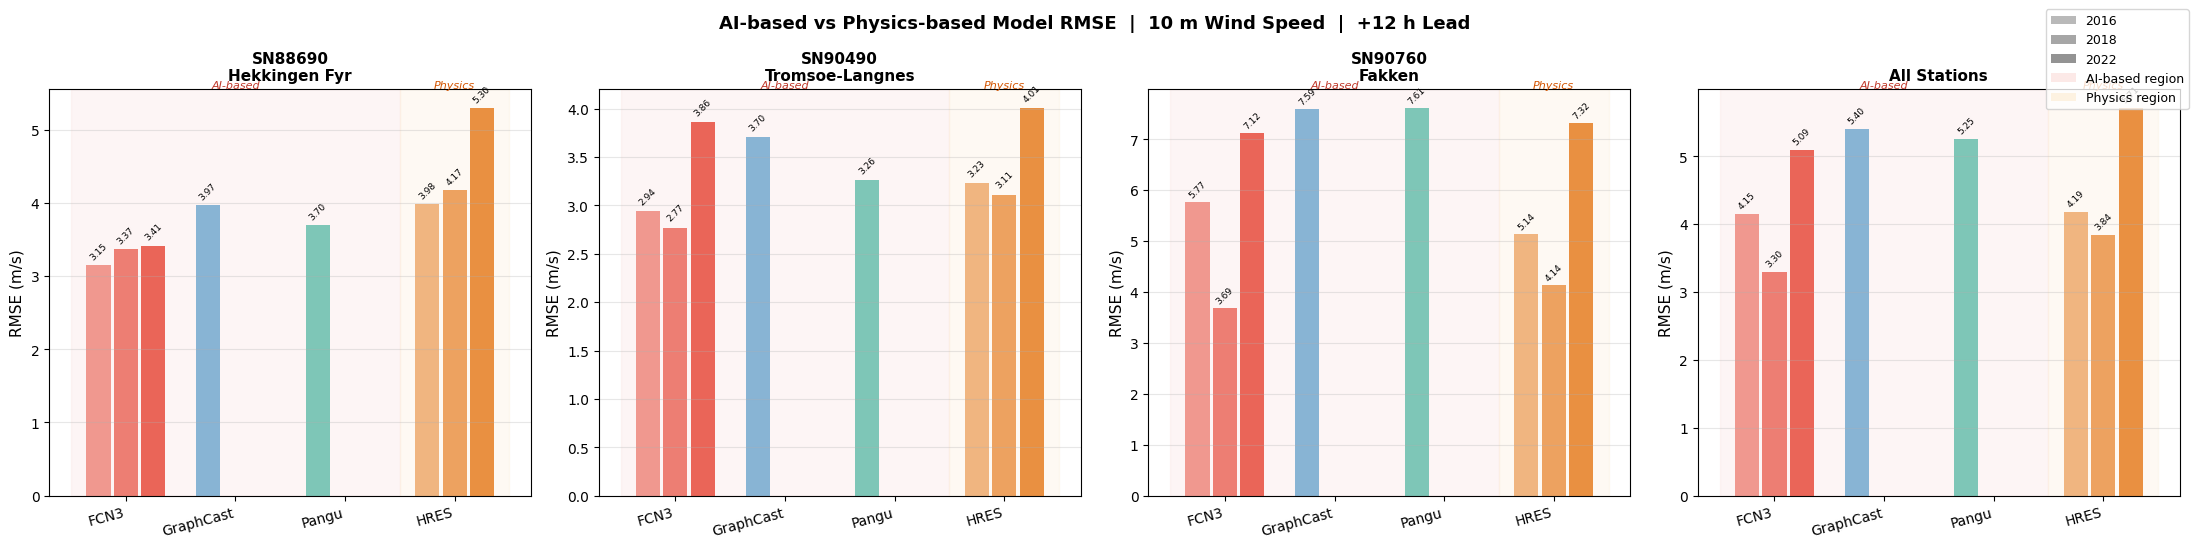

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/comparison_summary/ai_vs_physics_rmse.png


In [65]:
# ── Plot 1: AI vs Physics-based model performance ──────────────────────────
# Show RMSE for each model per year; shade AI vs Physics background.
# X-axis = models; groups = years; facets = stations

sids_all = list(STATIONS.keys()) + ['All Stations']
years    = [y for y in ['2016', '2018', '2022'] if y in dfs]

fig, axes = plt.subplots(1, len(sids_all), figsize=(5.5 * len(sids_all), 5.5), squeeze=False)
axes = axes[0]

YEAR_MARKERS = {'2016': 'o', '2018': 's', '2022': '^'}
YEAR_LINESTYLES = {'2016': '-', '2018': '--', '2022': ':'}

# Collect all models that appear across any year
all_models_ordered = ['FCN3', 'GraphCast', 'Pangu', 'HRES']

for col, sid in enumerate(sids_all):
    ax = axes[col]
    x_ticks, x_labels = [], []

    for i, model in enumerate(all_models_ordered):
        rmse_col = f'{model} RMSE'
        vals_by_year = {}
        for yr in years:
            if yr not in dfs: continue
            df = dfs[yr]
            if rmse_col not in df.columns: continue
            if sid not in df.index: continue
            vals_by_year[yr] = float(df.loc[sid, rmse_col])

        if not vals_by_year:
            continue

        # Bar for each year at position i, slightly offset
        n_yrs = len(vals_by_year)
        offsets = np.linspace(-0.25, 0.25, n_yrs)
        for j, (yr, rmse) in enumerate(sorted(vals_by_year.items())):
            clr = CLR.get(model, 'gray')
            alpha = 0.55 + 0.15 * j
            bar = ax.bar(i + offsets[j], rmse, 0.22, color=clr, alpha=alpha,
                         label=f'{model} {yr}' if col == 0 else '_')
            ax.text(i + offsets[j], rmse + 0.05, f'{rmse:.2f}',
                    ha='center', va='bottom', fontsize=6.5, rotation=45)

        x_ticks.append(i)
        x_labels.append(model)

    # Shade AI vs Physics regions
    n_ai = sum(1 for m in all_models_ordered if m in AI_MODELS and
               any(f'{m} RMSE' in dfs[y].columns for y in years if y in dfs))
    if n_ai > 0:
        ax.axvspan(-0.5, n_ai - 0.5, color='#FADBD8', alpha=0.25, zorder=0)
        ax.axvspan(n_ai - 0.5, len(all_models_ordered) - 0.5,
                   color='#FDEBD0', alpha=0.25, zorder=0)
        ax.text(n_ai / 2 - 0.5, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 5,
                'AI-based', ha='center', fontsize=8, color='#C0392B', style='italic')
        ax.text(n_ai + (len([m for m in all_models_ordered if m in PHYSICS_MODELS])) / 2 - 0.5,
                ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 5,
                'Physics', ha='center', fontsize=8, color='#D35400', style='italic')

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, fontsize=10, rotation=15, ha='right')
    ax.set_ylabel('RMSE (m/s)', fontsize=11)
    label = STATIONS.get(sid, sid)
    ax.set_title(f'{sid}' + (f'\n{label}' if sid != 'All Stations' else ''), fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

# Manual legend for years
from matplotlib.patches import Patch
handles = [Patch(facecolor='gray', alpha=0.55+0.15*j, label=yr)
           for j, yr in enumerate(sorted(years))]
handles += [Patch(facecolor='#FADBD8', alpha=0.6, label='AI-based region'),
            Patch(facecolor='#FDEBD0', alpha=0.6, label='Physics region')]
fig.legend(handles=handles, fontsize=9, loc='upper right', bbox_to_anchor=(1, 1))

fig.suptitle('AI-based vs Physics-based Model RMSE  |  10 m Wind Speed  |  +12 h Lead',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out = FIG_OUT / 'ai_vs_physics_rmse.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


## 3  RMSE Comparison Across Years (2016 / 2018 / 2022)

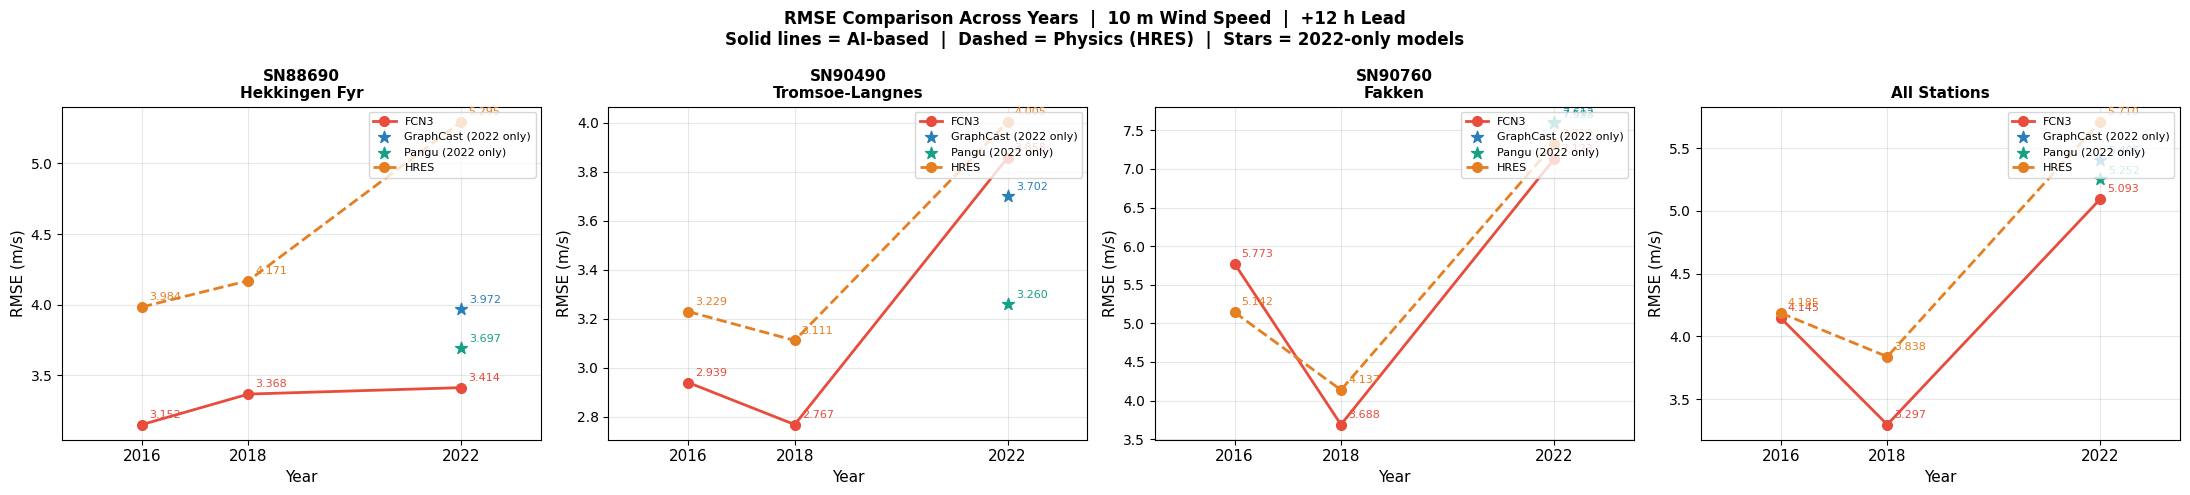

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/comparison_summary/rmse_across_years.png


In [66]:
# ── Plot 2: RMSE comparison across years ────────────────────────────────────
# Line chart: X = year, Y = RMSE, one line per model.
# GraphCast and Pangu are only available for 2022 (shown as isolated points).

years_num = {'2016': 2016, '2018': 2018, '2022': 2022}
sids_all  = list(STATIONS.keys()) + ['All Stations']

fig, axes = plt.subplots(1, len(sids_all), figsize=(5.5 * len(sids_all), 5), squeeze=False)
axes = axes[0]

for col, sid in enumerate(sids_all):
    ax = axes[col]

    for model in ['FCN3', 'GraphCast', 'Pangu', 'HRES']:
        rmse_col = f'{model} RMSE'
        pts = []
        for yr in sorted(years_num.keys()):
            if yr not in dfs: continue
            df = dfs[yr]
            if rmse_col not in df.columns: continue
            if sid not in df.index: continue
            pts.append((years_num[yr], float(df.loc[sid, rmse_col])))

        if not pts:
            continue

        xs = [p[0] for p in pts]
        ys = [p[1] for p in pts]
        clr = CLR.get(model, 'gray')

        if len(xs) == 1:
            # Only available for one year -> isolated point
            ax.scatter(xs, ys, color=clr, s=80, zorder=5,
                       marker='*', label=f'{model} (2022 only)')
            ax.annotate(f'{ys[0]:.3f}', (xs[0], ys[0]),
                        textcoords='offset points', xytext=(6, 4), fontsize=8, color=clr)
        else:
            ls = '-' if model in AI_MODELS else '--'
            ax.plot(xs, ys, color=clr, lw=2.0, linestyle=ls, marker='o', ms=7, label=model)
            for x, y in zip(xs, ys):
                ax.annotate(f'{y:.3f}', (x, y),
                            textcoords='offset points', xytext=(5, 5), fontsize=8, color=clr)

    ax.set_xticks(sorted(years_num.values()))
    ax.set_xticklabels(sorted(years_num.keys()), fontsize=11)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('RMSE (m/s)', fontsize=11)
    label = STATIONS.get(sid, sid)
    ax.set_title(f'{sid}' + (f'\n{label}' if sid != 'All Stations' else ''), fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)
    ax.set_xlim(2014.5, 2023.5)

fig.suptitle('RMSE Comparison Across Years  |  10 m Wind Speed  |  +12 h Lead\n'
             'Solid lines = AI-based  |  Dashed = Physics (HRES)  |  Stars = 2022-only models',
             fontsize=12, fontweight='bold')
plt.tight_layout()
out = FIG_OUT / 'rmse_across_years.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


## 4  Three-Year Integrated Bar Chart

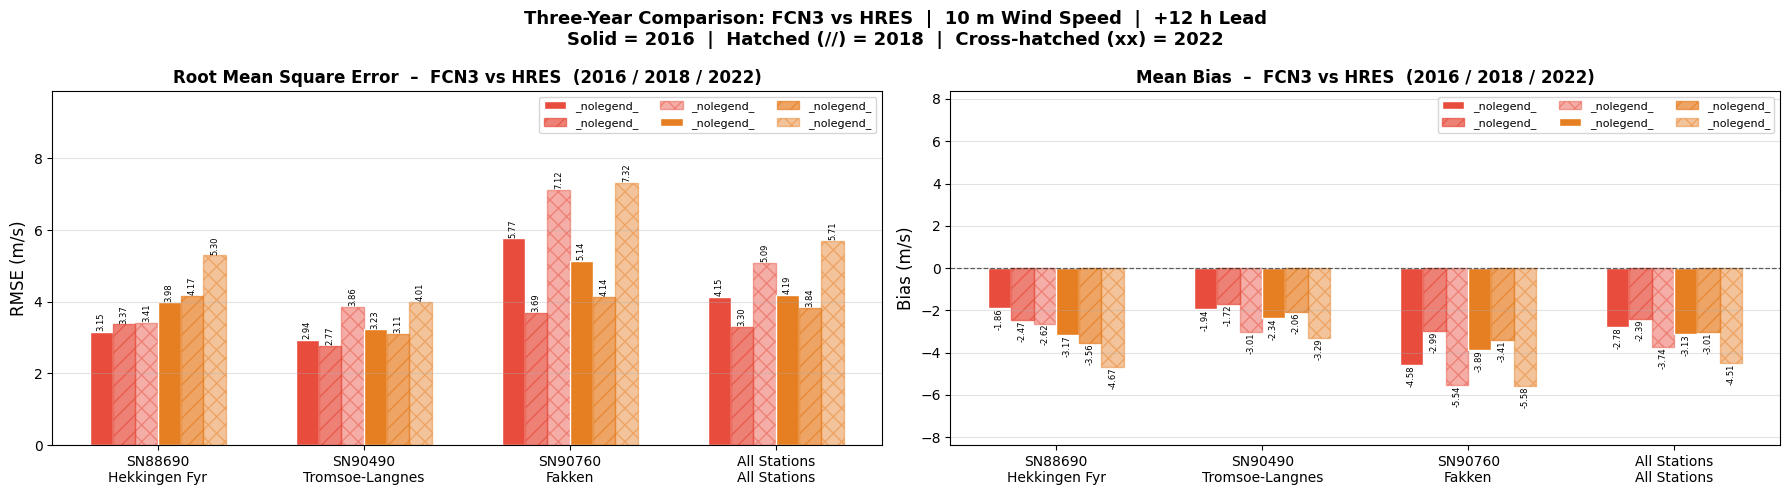

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/comparison_summary/three_year_bar_chart.png


In [67]:
# ── Plot 3: Three-year integrated bar chart ─────────────────────────────────
# FCN3 vs HRES across 2016 / 2018 / 2022 – RMSE and Bias per station.
# Groups on X-axis = stations; within each group, bars ordered by model then year.

years         = [y for y in ['2016', '2018', '2022'] if y in dfs]
models_2year  = ['FCN3', 'HRES']   # available in all three years
sids_all      = list(STATIONS.keys()) + ['All Stations']
labels        = [f'{s}\n{STATIONS.get(s, s)}' for s in sids_all]

x        = np.arange(len(sids_all))
n_combos = len(models_2year) * len(years)
w        = 0.11
offsets  = np.linspace(-(n_combos - 1) / 2, (n_combos - 1) / 2, n_combos) * w

YEAR_ALPHA = {'2016': 1.00, '2018': 0.70, '2022': 0.45}
YEAR_HATCH = {'2016': '',   '2018': '//', '2022': 'xx'}

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, (metric, ylabel, title) in zip(
    axes,
    [('RMSE', 'RMSE (m/s)', 'Root Mean Square Error  –  FCN3 vs HRES  (2016 / 2018 / 2022)'),
     ('Bias', 'Bias (m/s)', 'Mean Bias  –  FCN3 vs HRES  (2016 / 2018 / 2022)')],
):
    bar_handles = []
    idx = 0
    for model in models_2year:
        clr = CLR[model]
        for yr in years:
            df = dfs.get(yr)
            col = f'{model} {metric}'
            if df is None or col not in df.columns:
                idx += 1
                continue

            vals = [float(df.loc[sid, col]) if sid in df.index else np.nan
                    for sid in sids_all]
            bars = ax.bar(
                x + offsets[idx], vals, w,
                color=clr,
                alpha=YEAR_ALPHA[yr],
                hatch=YEAR_HATCH[yr],
                edgecolor='white' if not YEAR_HATCH[yr] else clr,
                label=f'{model} {yr}',
            )
            bar_handles.append(bars[0])

            for bar, v in zip(bars, vals):
                if not np.isnan(v):
                    h = bar.get_height()
                    sign = 1 if h >= 0 else -1
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        h + sign * 0.02,
                        f'{v:+.2f}' if metric == 'Bias' else f'{v:.2f}',
                        ha='center',
                        va='bottom' if h >= 0 else 'top',
                        fontsize=6,
                        rotation=90,
                    )
            idx += 1

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(handles=bar_handles, fontsize=8, ncol=3, loc='upper right')
    ax.grid(axis='y', alpha=0.35)

    if metric == 'Bias':
        ax.axhline(0, color='k', lw=0.9, linestyle='--', alpha=0.6)
        all_vals = [float(dfs[yr].loc[sid, f'{m} Bias'])
                    for yr in years for m in models_2year for sid in sids_all
                    if yr in dfs and f'{m} Bias' in dfs[yr].columns and sid in dfs[yr].index]
        if all_vals:
            lim = max(abs(v) for v in all_vals) * 1.5
            ax.set_ylim(-lim, lim)
    else:
        all_vals = [float(dfs[yr].loc[sid, f'{m} RMSE'])
                    for yr in years for m in models_2year for sid in sids_all
                    if yr in dfs and f'{m} RMSE' in dfs[yr].columns and sid in dfs[yr].index]
        if all_vals:
            ax.set_ylim(0, max(all_vals) * 1.35)

fig.suptitle(
    'Three-Year Comparison: FCN3 vs HRES  |  10 m Wind Speed  |  +12 h Lead\n'
    'Solid = 2016  |  Hatched (//) = 2018  |  Cross-hatched (xx) = 2022',
    fontsize=13, fontweight='bold',
)
plt.tight_layout()
out = FIG_OUT / 'three_year_bar_chart.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


## 5  Combined Metrics Table

In [68]:
# ── Print combined metrics table ────────────────────────────────────────────
rows = []
for yr, df in sorted(dfs.items()):
    rmse_cols = [c for c in df.columns if 'RMSE' in c]
    bias_cols = [c for c in df.columns if 'Bias' in c]
    for sid in list(STATIONS.keys()) + ['All Stations']:
        if sid not in df.index: continue
        row = {'Year': yr, 'Station': sid}
        for c in rmse_cols + bias_cols:
            row[c] = round(float(df.loc[sid, c]), 4)
        rows.append(row)

table = pd.DataFrame(rows)
print('Combined Metrics  |  +12 h Lead  |  All Years')
print('=' * 100)
print(table.to_string(index=False))


Combined Metrics  |  +12 h Lead  |  All Years
Year      Station  FCN3 RMSE  HRES RMSE  ΔRMSE HRES−FCN3  FCN3 Bias  HRES Bias  GraphCast RMSE  Pangu RMSE  ΔRMSE GraphCast−FCN3  ΔRMSE Pangu−FCN3  GraphCast Bias  Pangu Bias
2016      SN88690     3.1524     3.9845           0.8321    -1.8634    -3.1701             NaN         NaN                   NaN               NaN             NaN         NaN
2016      SN90490     2.9390     3.2290           0.2899    -1.9428    -2.3413             NaN         NaN                   NaN               NaN             NaN         NaN
2016      SN90760     5.7727     5.1424          -0.6303    -4.5827    -3.8854             NaN         NaN                   NaN               NaN             NaN         NaN
2016 All Stations     4.1450     4.1853           0.0403    -2.7831    -3.1267             NaN         NaN                   NaN               NaN             NaN         NaN
2018      SN88690     3.3682     4.1706           0.8025    -2.4677    -3.5592 

## 6  RMSE & Bias Bar Charts – Three Years

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.transforms import blended_transform_factory
from pathlib import Path

FIG_OUT = Path('/cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/comparison_summary')
FIG_OUT.mkdir(parents=True, exist_ok=True)

DATA = {
    '2016': {
        'SN88690':     {'FCN3': (3.1524, -1.8634), 'HRES': (3.9845, -3.1701)},
        'SN90490':     {'FCN3': (2.9390, -1.9428), 'HRES': (3.2290, -2.3413)},
        'SN90760':     {'FCN3': (5.7727, -4.5827), 'HRES': (5.1424, -3.8854)},
        'All Stations':{'FCN3': (4.1450, -2.7831), 'HRES': (4.1853, -3.1267)},
    },
    '2018': {
        'SN88690':     {'FCN3': (3.3682, -2.4677), 'HRES': (4.1706, -3.5592)},
        'SN90490':     {'FCN3': (2.7673, -1.7212), 'HRES': (3.1110, -2.0627)},
        'SN90760':     {'FCN3': (3.6882, -2.9925), 'HRES': (4.1369, -3.4069)},
        'All Stations':{'FCN3': (3.2967, -2.3938), 'HRES': (3.8378, -3.0096)},
    },
    '2022': {
        'SN88690':     {'FCN3': (3.4137, -2.6220), 'GraphCast': (3.9718, -3.1958), 'Pangu': (3.6972, -2.8022), 'HRES': (5.2953, -4.6672)},
        'SN90490':     {'FCN3': (3.8582, -3.0091), 'GraphCast': (3.7023, -3.0232), 'Pangu': (3.2600, -2.3904), 'HRES': (4.0051, -3.2906)},
        'SN90760':     {'FCN3': (7.1233, -5.5375), 'GraphCast': (7.5934, -6.1375), 'Pangu': (7.6117, -6.0846), 'HRES': (7.3187, -5.5803)},
        'All Stations':{'FCN3': (5.0928, -3.7366), 'GraphCast': (5.4049, -4.1304), 'Pangu': (5.2520, -3.7710), 'HRES': (5.7100, -4.5108)},
    },
}

SIDS      = ['SN88690', 'SN90490', 'SN90760', 'All Stations']
SID_NAMES = {'SN88690': 'Hekkingen Fyr', 'SN90490': 'Tromsø-Langnes',
             'SN90760': 'Fakken',         'All Stations': ''}
YEARS     = ['2016', '2018', '2022']
CLR       = {'FCN3': '#E74C3C', 'GraphCast': '#2980B9', 'Pangu': '#16A085', 'HRES': '#E67E22'}

# Models available per year (controls bar-group width and ordering)
YEAR_MODELS = {
    '2016': ['FCN3', 'HRES'],
    '2018': ['FCN3', 'HRES'],
    '2022': ['FCN3', 'GraphCast', 'Pangu', 'HRES'],
}

# ── Layout parameters ─────────────────────────────────────────────────────────
w            = 0.20   # bar width
yr_gap_close = 0.12   # gap between 2016 and 2018 (same 2-model years)
yr_gap_far   = 0.40   # gap between 2018 and 2022 (model count jumps 2→4)
sid_gap      = 0.70   # gap between station groups

YR_GAPS = {('2016', '2018'): yr_gap_close, ('2018', '2022'): yr_gap_far}

yr_tick_x = {}   # (sid, yr) → x center of year group
sid_span  = {}   # sid       → (left_edge, right_edge)

pos = 0.0
for sid in SIDS:
    first_left = pos
    for i_yr, yr in enumerate(YEARS):
        n        = len(YEAR_MODELS[yr])
        center   = pos + (n - 1) / 2.0 * w
        yr_tick_x[(sid, yr)] = center
        pos += n * w
        if i_yr < len(YEARS) - 1:
            pos += YR_GAPS[(yr, YEARS[i_yr + 1])]
    sid_span[sid] = (first_left, pos)
    pos += sid_gap


def bar_xpos(sid, yr, model):
    """Center x of bar for (station, year, model). Returns None if model not in year."""
    mlist = YEAR_MODELS[yr]
    if model not in mlist:
        return None
    j    = mlist.index(model)
    left = yr_tick_x[(sid, yr)] - (len(mlist) - 1) / 2.0 * w
    return left + j * w


### RMSE

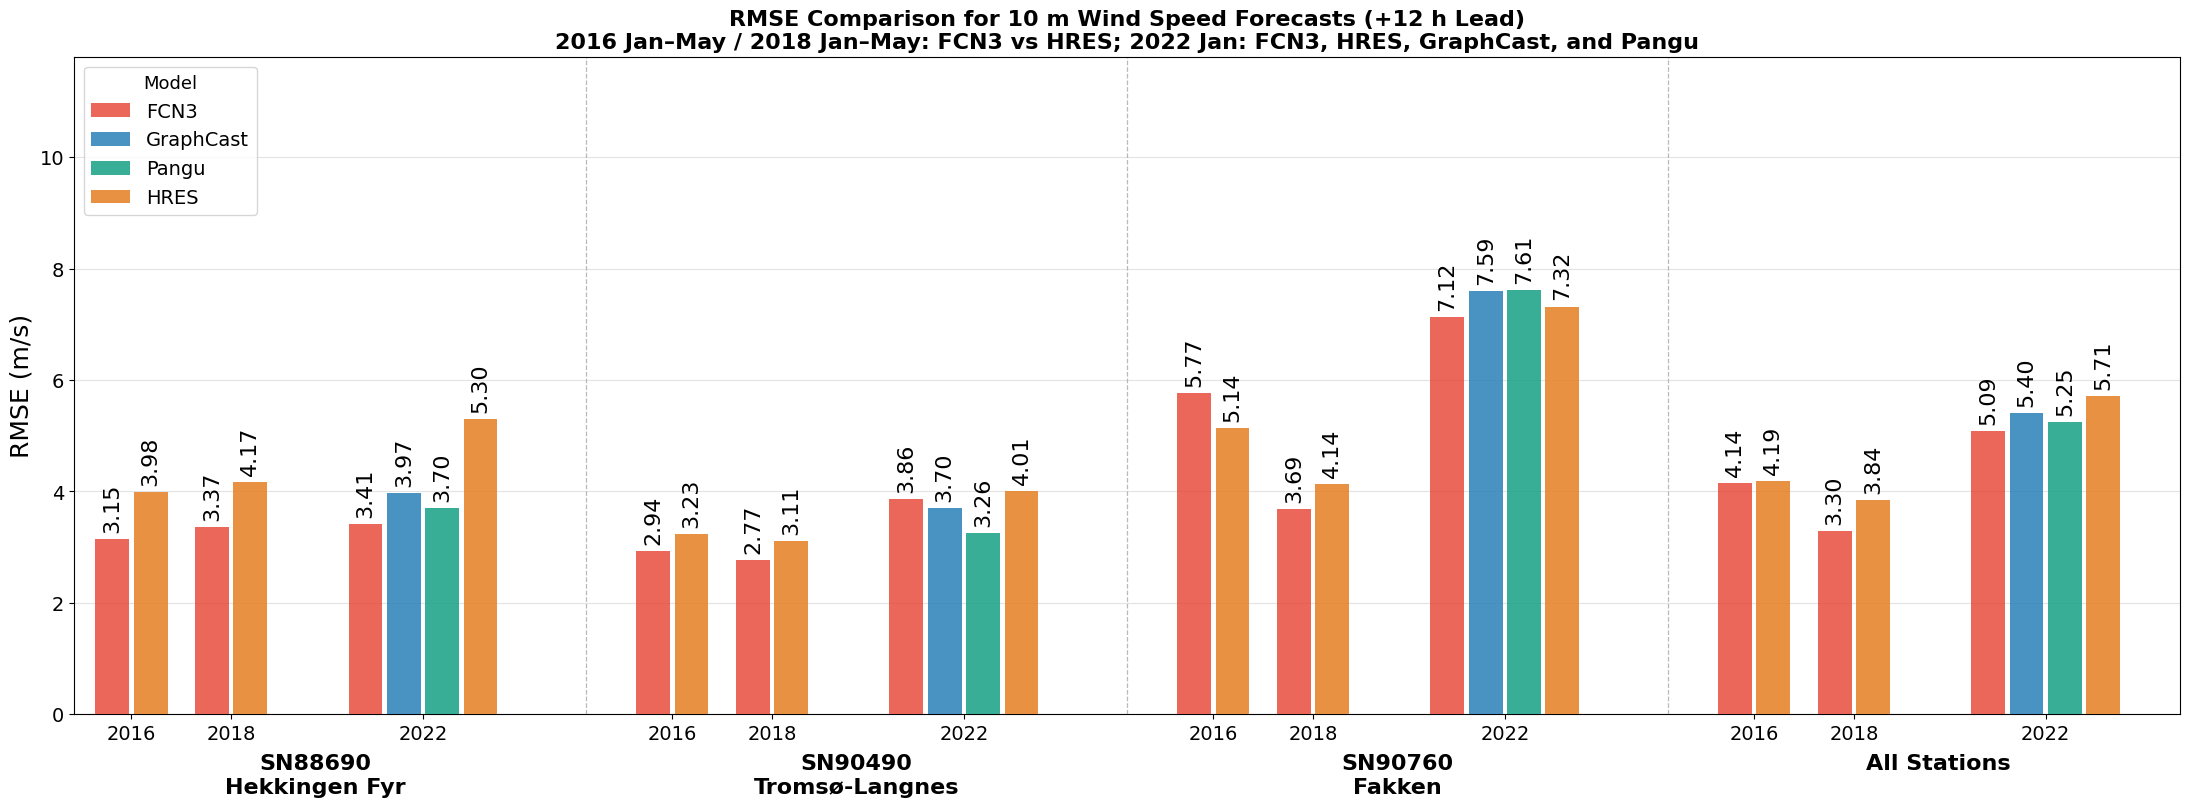

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/comparison_summary/bar_rmse_3yr.png


In [74]:
# ── Figure 1: RMSE ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 8))

all_vals = []
for sid in SIDS:
    for yr in YEARS:
        for model in YEAR_MODELS[yr]:
            if model not in DATA[yr].get(sid, {}):
                continue
            val = DATA[yr][sid][model][0]
            all_vals.append(val)
            xp  = bar_xpos(sid, yr, model)
            ax.bar(xp, val, w * 0.88, color=CLR[model], alpha=0.85, zorder=3)
            ax.text(xp, val + 0.12, f'{val:.2f}',
                    ha='center', va='bottom', fontsize=16, rotation=90)

ax.set_xticks([yr_tick_x[(sid, yr)] for sid in SIDS for yr in YEARS])
ax.set_xticklabels([yr for _ in SIDS for yr in YEARS], fontsize=14)

trans = blended_transform_factory(ax.transData, ax.transAxes)
for sid in SIDS:
    xmid = (sid_span[sid][0] + sid_span[sid][1]) / 2
    name = SID_NAMES[sid]
    label = f'{sid}' + (f'\n{name}' if name else '')
    ax.text(xmid, -0.06, label, transform=trans, ha='center', va='top',
            fontsize=16, fontweight='bold', clip_on=False)

for sid in SIDS[:-1]:
    nxt = SIDS[SIDS.index(sid) + 1]
    sep = (sid_span[sid][1] + sid_span[nxt][0]) / 2
    ax.axvline(sep, color='gray', lw=0.9, linestyle='--', alpha=0.55, zorder=1)

ax.set_xlim(sid_span[SIDS[0]][0] - w, sid_span[SIDS[-1]][1] + w)
ax.set_ylim(0, max(all_vals) * 1.55)
ax.set_ylabel('RMSE (m/s)', fontsize=18)
ax.grid(axis='y', alpha=0.35, zorder=0)
ax.tick_params(axis='y', labelsize=14)

models_all = ['FCN3', 'GraphCast', 'Pangu', 'HRES']
handles = [mpatches.Patch(facecolor=CLR[m], alpha=0.85, label=m) for m in models_all]
ax.legend(handles=handles, fontsize=14, loc='upper left',
          title='Model', title_fontsize=13)

ax.set_title(
    'RMSE Comparison for 10 m Wind Speed Forecasts (+12 h Lead)\n'
    '2016 Jan–May / 2018 Jan–May: FCN3 vs HRES; 2022 Jan: FCN3, HRES, GraphCast, and Pangu',
    fontsize=16, fontweight='bold',
)
plt.tight_layout()
plt.subplots_adjust(bottom=0.10)
out = FIG_OUT / 'bar_rmse_3yr.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


### Bias

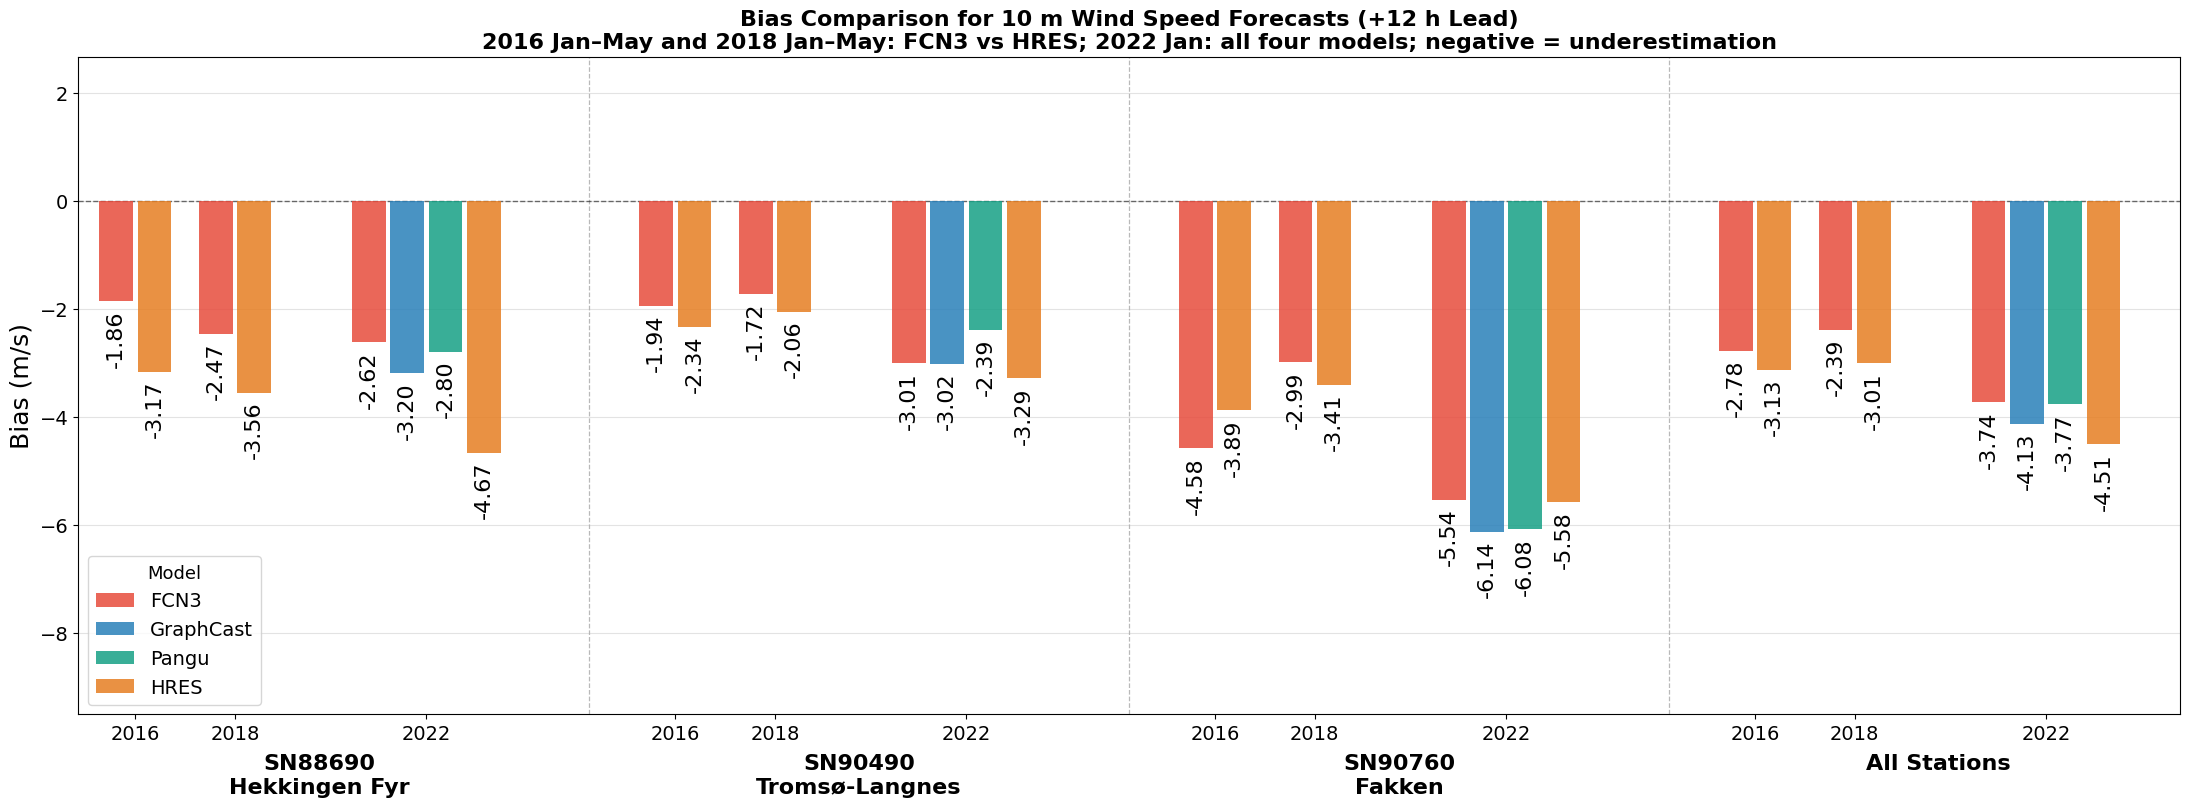

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/comparison_summary/bar_bias_3yr.png


In [75]:
# ── Figure 2: Bias ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 8))

all_abs = []
for sid in SIDS:
    for yr in YEARS:
        for model in YEAR_MODELS[yr]:
            if model not in DATA[yr].get(sid, {}):
                continue
            val = DATA[yr][sid][model][1]
            all_abs.append(abs(val))
            xp  = bar_xpos(sid, yr, model)
            ax.bar(xp, val, w * 0.88, color=CLR[model], alpha=0.85, zorder=3)
            ax.text(xp, val - 0.15, f'{val:+.2f}',
                    ha='center', va='top', fontsize=16, rotation=90)

ax.axhline(0, color='k', lw=1.0, linestyle='--', alpha=0.55, zorder=2)

ax.set_xticks([yr_tick_x[(sid, yr)] for sid in SIDS for yr in YEARS])
ax.set_xticklabels([yr for _ in SIDS for yr in YEARS], fontsize=14)

trans = blended_transform_factory(ax.transData, ax.transAxes)
for sid in SIDS:
    xmid = (sid_span[sid][0] + sid_span[sid][1]) / 2
    name = SID_NAMES[sid]
    label = f'{sid}' + (f'\n{name}' if name else '')
    ax.text(xmid, -0.06, label, transform=trans, ha='center', va='top',
            fontsize=16, fontweight='bold', clip_on=False)

for sid in SIDS[:-1]:
    nxt = SIDS[SIDS.index(sid) + 1]
    sep = (sid_span[sid][1] + sid_span[nxt][0]) / 2
    ax.axvline(sep, color='gray', lw=0.9, linestyle='--', alpha=0.55, zorder=1)

ax.set_xlim(sid_span[SIDS[0]][0] - w, sid_span[SIDS[-1]][1] + w)
lim = max(all_abs) * 1.55 if all_abs else 8
ax.set_ylim(-lim, lim * 0.28)
ax.set_ylabel('Bias (m/s)', fontsize=18)
ax.grid(axis='y', alpha=0.35, zorder=0)
ax.tick_params(axis='y', labelsize=14)

models_all = ['FCN3', 'GraphCast', 'Pangu', 'HRES']
handles = [mpatches.Patch(facecolor=CLR[m], alpha=0.85, label=m) for m in models_all]
ax.legend(handles=handles, fontsize=14, loc='lower left',
          title='Model', title_fontsize=13)

ax.set_title(
    'Bias Comparison for 10 m Wind Speed Forecasts (+12 h Lead)\n'
    '2016 Jan–May and 2018 Jan–May: FCN3 vs HRES; 2022 Jan: all four models; negative = underestimation',
    fontsize=16, fontweight='bold',
)
plt.tight_layout()
plt.subplots_adjust(bottom=0.10)
out = FIG_OUT / 'bar_bias_3yr.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')
